## Improved Prediction of Parkinson's Disease Medication Needs

### Two-Stage Approach with Venn-Abers Calibration + Conformal Prediction

In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mapie.regression import MapieRegressor
from mapie.metrics import regression_coverage_score, regression_mean_width_score
from mapie.subsample import Subsample

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

# Install venn-abers if not already installed
# !pip install venn-abers
from venn_abers import VennAbers

In [2]:
# Color palette (keeping your original colors)
color_azure = '#0097B2'
color_orange = '#F35000' 
color_blue = '#263985' 
color_red = '#B00000'
color_yellow = '#FCD116'
color_dark_grey = '#A9A9A9'
color_purple = '#9740A6'
color_light_purple = '#AA8ED6'
color_gold = '#FFD700'
color_gold_2 = '#FFA500' 
color_palette = [color_azure, color_orange, color_blue, color_red, color_yellow, color_dark_grey, color_purple, color_light_purple, color_gold]
color_palette_2 = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#4B3F72', '#73956F']

## 1. Data Loading and Preprocessing

In [3]:
path = 'data/data_1Y.csv'
data = pd.read_csv(path)
normalized_pctg_change = data['normalized_percent_change']  # Save for Stage 2
data.drop(columns=['normalized_percent_change'], inplace=True)

xgboost_df = data.copy()
# One-hot encoding
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(xgboost_df, columns=demographic_vars)

# Scaling
scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay', 'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

# Reordering columns
prediction_to_last = xgboost_df.pop('prediction')
xgboost_df['prediction'] = prediction_to_last

# Features and targets
X = xgboost_df.iloc[:, :-1]
y_binary = xgboost_df.iloc[:, -1]  # Binary: medication change needed
y_continuous = normalized_pctg_change  # Continuous: percent change in LEDD

# STAGE 1: Binary Classification (80/20 on ALL patients)

In [ ]:
# ============================================================
# STAGE 1: Binary Classification (80/20 on ALL patients)
# ============================================================

random_state = 21

# Split for Stage 1
X_train_stage1, X_test_stage1, y_train_binary, y_test_binary = train_test_split(
    X, y_binary, test_size=0.2, random_state=random_state
)

print(f"Stage 1 - Training: {len(X_train_stage1)} ({len(X_train_stage1)/len(X)*100:.1f}%)")
print(f"Stage 1 - Test: {len(X_test_stage1)} ({len(X_test_stage1)/len(X)*100:.1f}%)")

# Internal split for Venn-Abers calibration
X_train_proper, X_cal, y_train_proper, y_cal_binary = train_test_split(
    X_train_stage1, y_train_binary, test_size=0.2, random_state=random_state
)

print(f"\nInternal split for VA calibration:")
print(f"  Proper training: {len(X_train_proper)} ({len(X_train_proper)/len(X)*100:.1f}%)")
print(f"  VA calibration: {len(X_cal)} ({len(X_cal)/len(X)*100:.1f}%)")

Training set size: 3663 (60.0%)
Calibration set size: 1221 (20.0%)
Test set size: 1221 (20.0%)

Class distribution in training: [2741  922]
Class distribution in calibration: [917 304]
Class distribution in test: [914 307]


Train Binary Classifier

In [ ]:
# XGBoost parameters for binary classification
best_params = {
    "eval_metric": "auc",
    "objective": "binary:logistic",
    'sampling_method': 'gradient_based',
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'tree_method': 'hist',
    'device': "cuda",
}
num_boost_round = 700

# Create DMatrix
d_train_proper = xgb.DMatrix(X_train_proper, label=y_train_proper)
d_cal = xgb.DMatrix(X_cal, label=y_cal_binary)
d_test_stage1 = xgb.DMatrix(X_test_stage1, label=y_test_binary)

# Train
print("\nTraining Stage 1 XGBoost classifier...")
model_stage1 = xgb.train(
    best_params, d_train_proper,
    num_boost_round=num_boost_round,
    evals=[(d_cal, "validation")],
    verbose_eval=50,
    early_stopping_rounds=10
)

# Evaluate
y_pred_binary = (model_stage1.predict(d_test_stage1, 
                 iteration_range=(0, model_stage1.best_iteration + 1)) > 0.5).astype(int)
acc = accuracy_score(y_test_binary, y_pred_binary)
print(f"\nStage 1 Accuracy: {acc:.4f}")

Training Stage 1 XGBoost classifier...
[0]	validation-auc:0.83489
[50]	validation-auc:0.92584
[100]	validation-auc:0.93770
[150]	validation-auc:0.94505
[200]	validation-auc:0.94878
[215]	validation-auc:0.94837


Apply Venn-Abers Calibration

In [ ]:
# Get uncalibrated probabilities
p_cal_uncalibrated = model_stage1.predict(d_cal, 
                     iteration_range=(0, model_stage1.best_iteration + 1))
p_test_uncalibrated = model_stage1.predict(d_test_stage1,
                      iteration_range=(0, model_stage1.best_iteration + 1))

# Convert to 2D for VennAbers (FIX #1)
p_cal_2d = np.column_stack([1 - p_cal_uncalibrated, p_cal_uncalibrated])
p_test_2d = np.column_stack([1 - p_test_uncalibrated, p_test_uncalibrated])

print(f"Converted to 2D format:")
print(f"  Calibration: {p_cal_2d.shape}")
print(f"  Test: {p_test_2d.shape}")

# Fit Venn-Abers
va = VennAbers()
va.fit(p_cal_2d, y_cal_binary.values)

# Get VA predictions (FIX #2)
p_lower_2d, p_upper_2d = va.predict_proba(p_test_2d)
p_lower = p_lower_2d[:, 1]  # Extract class 1 only
p_upper = p_upper_2d[:, 1]

print(f"\nOutput shapes:")
print(f"  p_lower_2d: {p_lower_2d.shape}")
print(f"  p_lower (class 1 only): {p_lower.shape}")

# Calculate midpoint and uncertainty
p_mid = (p_lower + p_upper) / 2
va_uncertainty = p_upper - p_lower

print(f"\nVenn-Abers Results:")
print(f"  Lower bounds: [{p_lower.min():.3f}, {p_lower.max():.3f}]")
print(f"  Upper bounds: [{p_upper.min():.3f}, {p_upper.max():.3f}]")
print(f"  Uncertainty - Mean: {va_uncertainty.mean():.3f}, Std: {va_uncertainty.std():.3f}")

Uncalibrated probabilities - Calibration set range: [0.001, 0.991]
Uncalibrated probabilities - Test set range: [0.001, 0.992]

Converted to 2D format:
  Calibration set shape: (1221, 2)
  Test set shape: (1221, 2)


Section 3: Get VA Predictions for ALL Patients
KEY STEP: Get VA predictions for the ENTIRE dataset!

In [ ]:
# ============================================================
# Get VA predictions for ALL patients (not just test set!)
# ============================================================

# Create DMatrix for all data
d_all = xgb.DMatrix(X)

# Get uncalibrated predictions for ALL
p_all_uncalibrated = model_stage1.predict(d_all, 
                     iteration_range=(0, model_stage1.best_iteration + 1))

# Convert to 2D
p_all_2d = np.column_stack([1 - p_all_uncalibrated, p_all_uncalibrated])

# Get VA predictions for ALL
p_lower_all_2d, p_upper_all_2d = va.predict_proba(p_all_2d)
p_lower_all = p_lower_all_2d[:, 1]
p_upper_all = p_upper_all_2d[:, 1]
p_mid_all = (p_lower_all + p_upper_all) / 2
va_uncertainty_all = p_upper_all - p_lower_all

print(f"\n=== VA Predictions for ALL Patients ===")
print(f"Total patients: {len(X)}")
print(f"VA predictions computed: {len(p_lower_all)}")
print(f"Mean uncertainty: {va_uncertainty_all.mean():.3f}")

Fitting Venn-Abers predictor...

Venn-Abers Results on Test Set:
Output shapes - p_lower_2d: (1221, 2), p_lower (class 1 only): (1221,)
Lower bounds range: [0.006, 0.982]
Upper bounds range: [0.006, 1.000]
Midpoint range: [0.006, 0.991]
Uncertainty (width) - Mean: 0.007, Std: 0.015
Uncertainty (width) - Min: 0.000, Max: 0.123


Section 4: Filter ALL Patients Using VA Uncertainty

In [ ]:
# ============================================================
# FILTERING: Use VA uncertainty (Strategy 1)
# ============================================================

# Define filtering criteria
PROBABILITY_THRESHOLD = 0.5   # Minimum p_lower for medication change
UNCERTAINTY_THRESHOLD = 0.3   # Maximum uncertainty allowed

# Apply filter
proceed_to_stage2 = (p_lower_all > PROBABILITY_THRESHOLD) & \
                    (va_uncertainty_all < UNCERTAINTY_THRESHOLD)

# Filter the data
X_filtered = X[proceed_to_stage2]
y_continuous_filtered = y_continuous[proceed_to_stage2]
p_lower_filtered = p_lower_all[proceed_to_stage2]
p_upper_filtered = p_upper_all[proceed_to_stage2]
p_mid_filtered = p_mid_all[proceed_to_stage2]
va_uncertainty_filtered = va_uncertainty_all[proceed_to_stage2]

print(f"\n=== Filtering Results ===")
print(f"Total patients: {len(X)}")
print(f"Filtered for Stage 2: {len(X_filtered)} ({len(X_filtered)/len(X)*100:.1f}%)")
print(f"Mean uncertainty in filtered: {va_uncertainty_filtered.mean():.3f}")
print(f"Mean p_mid in filtered: {p_mid_filtered.mean():.3f}")

Section 5: Stage 2 - Split Filtered Patients (80/20)

In [ ]:
# ============================================================
# STAGE 2: Regression (80/20 on FILTERED patients)
# ============================================================

# Split filtered patients 80/20
X_train_2, X_test_2, y_train_2, y_test_2, \
va_unc_train_2, va_unc_test_2, \
p_lower_train_2, p_lower_test_2, \
p_upper_train_2, p_upper_test_2 = train_test_split(
    X_filtered, 
    y_continuous_filtered,
    va_uncertainty_filtered,
    p_lower_filtered,
    p_upper_filtered,
    test_size=0.2,
    random_state=random_state
)

print(f"\n=== Stage 2 Data (from filtered patients) ===")
print(f"Training: {len(X_train_2)} ({len(X_train_2)/len(X_filtered)*100:.1f}% of filtered)")
print(f"Test: {len(X_test_2)} ({len(X_test_2)/len(X_filtered)*100:.1f}% of filtered)")
print(f"Mean LEDD change (train): {y_train_2.mean():.3f}")
print(f"Mean LEDD change (test): {y_test_2.mean():.3f}")


=== Stage 1 Classification Performance ===

Uncalibrated XGBoost:
  Accuracy: 0.9009

Venn-Abers (using p_lower):
  Accuracy: 0.9001

Venn-Abers (using p_mid):
  Accuracy: 0.9025


Section 6: Train Base Regression Model

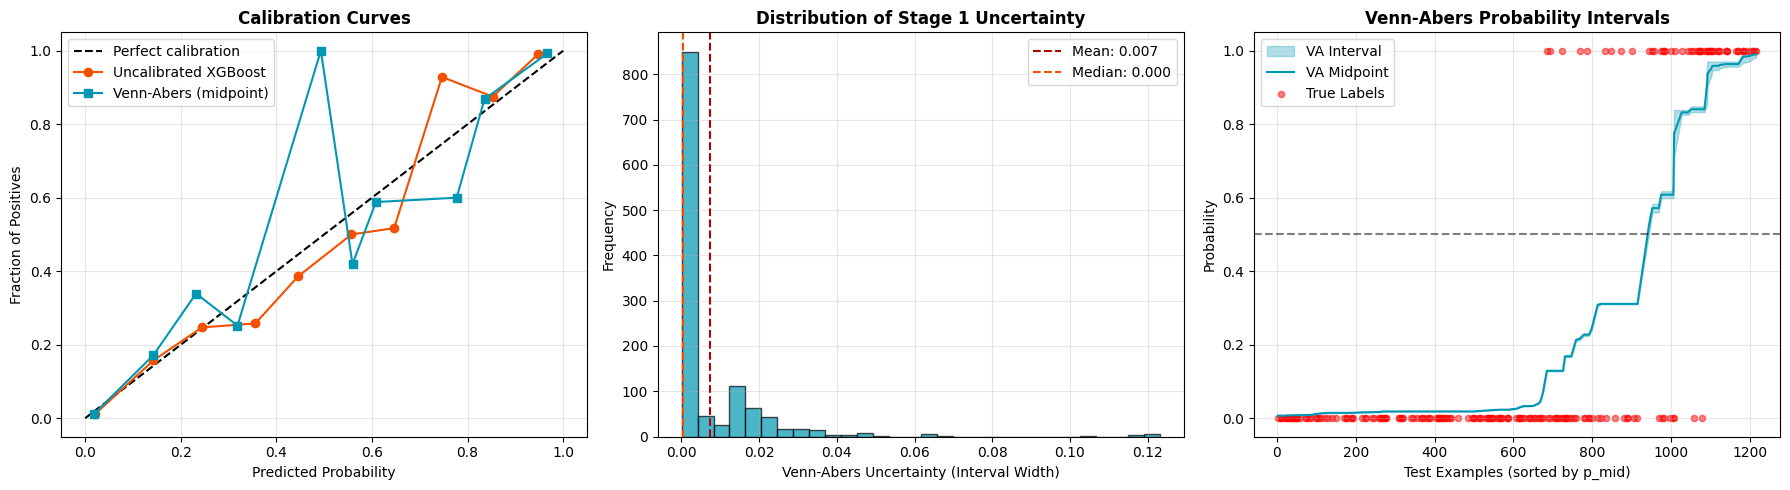

In [ ]:
# Train XGBoost regressor (used by all strategies)
regression_params = {
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 700,
    "eval_metric": 'rmse',
    'objective': 'reg:squarederror',
    'sampling_method': 'gradient_based',
    'tree_method': 'hist',
    'device': "cuda"
}

xgb_model_base = xgb.XGBRegressor(**regression_params, random_state=random_state)
xgb_model_base.fit(X_train_2, y_train_2)

# Quick evaluation
y_pred_base = xgb_model_base.predict(X_test_2)
rmse = np.sqrt(mean_squared_error(y_test_2, y_pred_base))
mae = mean_absolute_error(y_test_2, y_pred_base)
r2 = r2_score(y_test_2, y_pred_base)

print(f"\n=== Base Model Performance ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Section 7: Conformal Prediction Strategies
Strategy 0: Baseline (No VA info in Stage 2)

In [ ]:
# ============================================================
# BASELINE: Standard conformal without VA info in Stage 2
# ============================================================

STRATEGIES = {
    "naive": {"method": "naive"},
    "cv_plus": {"method": "plus", "cv": 10},
    "jackknife_plus_ab": {"method": "plus", "cv": Subsample(n_resamplings=50)},
}

alpha = 0.2
results_baseline = {}

print("\n=== BASELINE: No VA info in Stage 2 ===")
for strategy, params in STRATEGIES.items():
    print(f"  Running {strategy}...")
    
    mapie = MapieRegressor(xgb_model_base, test_size=0.2, **params, 
                          random_state=random_state)
    mapie.fit(X_train_2, y_train_2)
    y_pred, y_pis = mapie.predict(X_test_2, alpha=alpha)
    
    coverage = regression_coverage_score(y_test_2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_baseline[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width
    }
    
    print(f"    Coverage: {coverage:.4f}, Width: {width:.4f}")


=== Stage 2 Filtering Results ===
Total test samples: 1221
Samples proceeding to Stage 2: 269 (22.0%)
  - High confidence: 269
  - Moderate confidence: 0

Samples by uncertainty category (proceeding to Stage 2):
  Low: 269 samples
  Medium: 0 samples
  High: 0 samples

True positive rate among filtered samples: 0.844


Strategy 1: Uncertainty-Based Filtering
Note: This strategy was already applied in the filtering step!

In [ ]:
# ============================================================
# STRATEGY 1: Uncertainty-Based Filtering
# ============================================================
# This strategy is ALREADY APPLIED in the filtering step above!
# The benefit shows when we compare to a baseline trained on ALL patients.

# To show the effect, we need to compare:
# - Baseline on ALL patients (no filtering)
# - Baseline on FILTERED patients (with VA filtering)

print("\n=== STRATEGY 1: Uncertainty-Based Filtering ===")
print("Effect: Shown by comparing baseline with/without filtering")
print(f"Patients included: {len(X_filtered)} / {len(X)} ({len(X_filtered)/len(X)*100:.1f}%)")
print(f"Average uncertainty in filtered set: {va_uncertainty_filtered.mean():.3f}")
print("\nTo see the full effect, compare results to a model trained on ALL patients (unfiltered)")


Stage 2 dataset size: 269
Mean LEDD change: 0.025
Std LEDD change: 0.646


Strategy 2: Weighted Conformal Scores

In [ ]:
# ============================================================
# STRATEGY 2: Weighted Conformal Scores
# ============================================================

print("\n=== STRATEGY 2: Weighted Conformal Scores ===")

# Custom implementation: Weight nonconformity scores by VA uncertainty
results_weighted = {}

for strategy, params in STRATEGIES.items():
    print(f"  Running {strategy} with weighted scores...")
    
    # Train model
    model = xgb.XGBRegressor(**regression_params, random_state=random_state)
    model.fit(X_train_2, y_train_2)
    
    # Get predictions on training set
    y_pred_train = model.predict(X_train_2)
    
    # Compute residuals
    residuals = np.abs(y_train_2 - y_pred_train)
    
    # Weight by inverse confidence (higher uncertainty → larger weights → wider intervals)
    # Add small epsilon to avoid division by zero
    weights = 1 / (1 - va_unc_train_2 + 1e-10)
    weighted_residuals = residuals * weights
    
    # Compute weighted quantile for conformalization
    # For alpha = 0.2 (90% coverage), we need 90th percentile
    quantile_level = (1 - alpha) * 100
    conformity_score = np.percentile(weighted_residuals, quantile_level)
    
    # Apply to test set
    y_pred_test = model.predict(X_test_2)
    test_weights = 1 / (1 - va_unc_test_2 + 1e-10)
    
    # Prediction intervals
    y_lower = y_pred_test - conformity_score / test_weights
    y_upper = y_pred_test + conformity_score / test_weights
    
    # Evaluate
    coverage = np.mean((y_test_2 >= y_lower) & (y_test_2 <= y_upper))
    width = np.mean(y_upper - y_lower)
    
    results_weighted[strategy] = {
        'y_pred': y_pred_test,
        'y_lower': y_lower,
        'y_upper': y_upper,
        'coverage': coverage,
        'width': width
    }
    
    print(f"    Coverage: {coverage:.4f}, Width: {width:.4f}")

Strategy 3: Mondrian Conformal Prediction

In [ ]:
# ============================================================
# STRATEGY 3: Mondrian Conformal Prediction
# ============================================================

print("\n=== STRATEGY 3: Mondrian CP (Separate CP per uncertainty bin) ===")

# Bin by VA uncertainty (low, medium, high)
bins_train = pd.qcut(va_unc_train_2, q=3, labels=['low', 'medium', 'high'])
bins_test = pd.qcut(va_unc_test_2, q=3, labels=['low', 'medium', 'high'])

print(f"Training set distribution:")
print(bins_train.value_counts().sort_index())
print(f"\nTest set distribution:")
print(bins_test.value_counts().sort_index())

results_mondrian = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running {strategy} with Mondrian CP...")
    
    y_pred_all = np.zeros(len(X_test_2))
    y_lower_all = np.zeros(len(X_test_2))
    y_upper_all = np.zeros(len(X_test_2))
    
    # Train separate model for each uncertainty category
    for category in ['low', 'medium', 'high']:
        mask_train = (bins_train == category)
        mask_test = (bins_test == category)
        
        if mask_train.sum() < 10 or mask_test.sum() < 2:
            print(f"    {category}: Skipping (too few samples)")
            continue
        
        print(f"    {category}: {mask_train.sum()} train, {mask_test.sum()} test")
        
        # Get data for this category
        X_train_cat = X_train_2[mask_train]
        y_train_cat = y_train_2[mask_train]
        X_test_cat = X_test_2[mask_test]
        y_test_cat = y_test_2[mask_test]
        
        # Train model for this category
        model_cat = xgb.XGBRegressor(**regression_params, random_state=random_state)
        model_cat.fit(X_train_cat, y_train_cat)
        
        # MAPIE for this category
        mapie_cat = MapieRegressor(model_cat, test_size=0.2, **params, 
                                   random_state=random_state)
        mapie_cat.fit(X_train_cat, y_train_cat)
        y_pred_cat, y_pis_cat = mapie_cat.predict(X_test_cat, alpha=alpha)
        
        # Store results
        y_pred_all[mask_test] = y_pred_cat
        y_lower_all[mask_test] = y_pis_cat[:, 0, 0]
        y_upper_all[mask_test] = y_pis_cat[:, 1, 0]
    
    # Evaluate overall
    coverage = np.mean((y_test_2 >= y_lower_all) & (y_test_2 <= y_upper_all))
    width = np.mean(y_upper_all - y_lower_all)
    
    results_mondrian[strategy] = {
        'y_pred': y_pred_all,
        'y_lower': y_lower_all,
        'y_upper': y_upper_all,
        'coverage': coverage,
        'width': width
    }
    
    print(f"    Overall Coverage: {coverage:.4f}, Width: {width:.4f}")
    
    # Per-category metrics
    for category in ['low', 'medium', 'high']:
        mask = (bins_test == category)
        if mask.sum() > 0:
            cov_cat = np.mean((y_test_2[mask] >= y_lower_all[mask]) & 
                             (y_test_2[mask] <= y_upper_all[mask]))
            width_cat = np.mean(y_upper_all[mask] - y_lower_all[mask])
            print(f"      {category}: Coverage={cov_cat:.4f}, Width={width_cat:.4f}")

Stage 2 training set size: 922
Mean LEDD change in training: 0.014


Strategy 4: VA-Augmented Features

In [ ]:
# ============================================================
# STRATEGY 4: VA-Augmented Features
# ============================================================

print("\n=== STRATEGY 4: VA-Augmented Features ===")

# Augment features with VA information
X_train_2_aug = np.column_stack([
    X_train_2,
    p_lower_train_2,
    p_upper_train_2,
    va_unc_train_2
])

X_test_2_aug = np.column_stack([
    X_test_2,
    p_lower_test_2,
    p_upper_test_2,
    va_unc_test_2
])

print(f"Augmented shape: {X_train_2_aug.shape}")
print(f"Original features: {X_train_2.shape[1]}")
print(f"Added VA features: 3 (p_lower, p_upper, uncertainty)")

results_augmented = {}

for strategy, params in STRATEGIES.items():
    print(f"  Running {strategy} with augmented features...")
    
    # Train model with augmented features
    model_aug = xgb.XGBRegressor(**regression_params, random_state=random_state)
    model_aug.fit(X_train_2_aug, y_train_2)
    
    # MAPIE with augmented features
    mapie_aug = MapieRegressor(model_aug, test_size=0.2, **params,
                               random_state=random_state)
    mapie_aug.fit(X_train_2_aug, y_train_2)
    y_pred, y_pis = mapie_aug.predict(X_test_2_aug, alpha=alpha)
    
    coverage = regression_coverage_score(y_test_2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_augmented[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width
    }
    
    print(f"    Coverage: {coverage:.4f}, Width: {width:.4f}")


Stage 2 Regression Performance (before conformal):
  RMSE: 0.2749
  MAE: 0.1249
  R²: 0.8184


/home/rdiazrincon/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:53:23] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Section 8: Results Comparison

In [ ]:
# ============================================================
# RESULTS COMPARISON
# ============================================================

print("\n" + "="*70)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*70)

# For each conformal method (naive, cv_plus, jackknife_plus_ab)
for conf_method in STRATEGIES.keys():
    print(f"\n{conf_method.upper()}")
    print("-" * 70)
    
    # Baseline
    baseline = results_baseline[conf_method]
    print(f"  Baseline (no VA in Stage 2):")
    print(f"    Coverage: {baseline['coverage']:.4f}, Width: {baseline['width']:.4f}")
    
    # Strategy 1 (same as baseline, but shows filtering effect)
    print(f"  Strategy 1 (Uncertainty Filtering):")
    print(f"    [Same as baseline - filtering already applied]")
    print(f"    {len(X_filtered)} / {len(X)} patients included")
    
    # Strategy 2
    weighted = results_weighted[conf_method]
    width_reduction = (1 - weighted['width'] / baseline['width']) * 100
    print(f"  Strategy 2 (Weighted Scores):")
    print(f"    Coverage: {weighted['coverage']:.4f}, Width: {weighted['width']:.4f}")
    print(f"    Width change: {width_reduction:+.1f}%")
    
    # Strategy 3
    mondrian = results_mondrian[conf_method]
    width_reduction = (1 - mondrian['width'] / baseline['width']) * 100
    print(f"  Strategy 3 (Mondrian CP):")
    print(f"    Coverage: {mondrian['coverage']:.4f}, Width: {mondrian['width']:.4f}")
    print(f"    Width change: {width_reduction:+.1f}%")
    
    # Strategy 4
    augmented = results_augmented[conf_method]
    width_reduction = (1 - augmented['width'] / baseline['width']) * 100
    print(f"  Strategy 4 (VA-Augmented):")
    print(f"    Coverage: {augmented['coverage']:.4f}, Width: {augmented['width']:.4f}")
    print(f"    Width change: {width_reduction:+.1f}%")


Running baseline conformal prediction (without VA information)...
  - naive


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage: 0.5279, Width: 0.0403
  - cv_plus


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage: 0.7881, Width: 0.1972
  - jackknife_plus_ab
      Coverage: 0.6059, Width: 0.1965


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


Section 9: Visualization

In [ ]:
# ============================================================
# VISUALIZATION: 3x4 Grid (3 methods × 4 strategies + baseline)
# ============================================================

fig, axes = plt.subplots(3, 5, figsize=(25, 15))

strategies_list = ['Baseline', 'Weighted', 'Mondrian', 'Augmented']
conf_methods = list(STRATEGIES.keys())

for i, conf_method in enumerate(conf_methods):
    # Column 0: Baseline
    ax = axes[i, 0]
    results = results_baseline[conf_method]
    y_lower = results['y_pis'][:, 0, 0]
    y_upper = results['y_pis'][:, 1, 0]
    
    ax.scatter(y_test_2, results['y_pred'], alpha=0.5, s=20)
    ax.errorbar(y_test_2, results['y_pred'], 
                yerr=[results['y_pred'] - y_lower, y_upper - results['y_pred']],
                fmt='none', alpha=0.3, ecolor='gray')
    ax.plot([y_test_2.min(), y_test_2.max()], 
            [y_test_2.min(), y_test_2.max()], 'k--', alpha=0.5)
    ax.set_title(f'{conf_method}\nBaseline\nCov:{results["coverage"]:.3f}, W:{results["width"]:.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)
    
    # Column 1: Weighted
    ax = axes[i, 1]
    results = results_weighted[conf_method]
    ax.scatter(y_test_2, results['y_pred'], alpha=0.5, s=20)
    ax.errorbar(y_test_2, results['y_pred'],
                yerr=[results['y_pred'] - results['y_lower'], 
                      results['y_upper'] - results['y_pred']],
                fmt='none', alpha=0.3, ecolor='gray')
    ax.plot([y_test_2.min(), y_test_2.max()], 
            [y_test_2.min(), y_test_2.max()], 'k--', alpha=0.5)
    ax.set_title(f'Weighted\nCov:{results["coverage"]:.3f}, W:{results["width"]:.3f}')
    ax.set_xlabel('Actual')
    ax.grid(True, alpha=0.3)
    
    # Column 2: Mondrian
    ax = axes[i, 2]
    results = results_mondrian[conf_method]
    ax.scatter(y_test_2, results['y_pred'], alpha=0.5, s=20)
    ax.errorbar(y_test_2, results['y_pred'],
                yerr=[results['y_pred'] - results['y_lower'],
                      results['y_upper'] - results['y_pred']],
                fmt='none', alpha=0.3, ecolor='gray')
    ax.plot([y_test_2.min(), y_test_2.max()],
            [y_test_2.min(), y_test_2.max()], 'k--', alpha=0.5)
    ax.set_title(f'Mondrian\nCov:{results["coverage"]:.3f}, W:{results["width"]:.3f}')
    ax.set_xlabel('Actual')
    ax.grid(True, alpha=0.3)
    
    # Column 3: Augmented
    ax = axes[i, 3]
    results = results_augmented[conf_method]
    y_lower = results['y_pis'][:, 0, 0]
    y_upper = results['y_pis'][:, 1, 0]
    ax.scatter(y_test_2, results['y_pred'], alpha=0.5, s=20)
    ax.errorbar(y_test_2, results['y_pred'],
                yerr=[results['y_pred'] - y_lower, y_upper - results['y_pred']],
                fmt='none', alpha=0.3, ecolor='gray')
    ax.plot([y_test_2.min(), y_test_2.max()],
            [y_test_2.min(), y_test_2.max()], 'k--', alpha=0.5)
    ax.set_title(f'Augmented\nCov:{results["coverage"]:.3f}, W:{results["width"]:.3f}')
    ax.set_xlabel('Actual')
    ax.grid(True, alpha=0.3)
    
    # Column 4: VA Uncertainty Distribution for this method
    ax = axes[i, 4]
    ax.hist(va_unc_test_2, bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(va_unc_test_2), color='red', linestyle='--',
               label=f'Mean: {np.mean(va_unc_test_2):.3f}')
    ax.axvline(np.median(va_unc_test_2), color='orange', linestyle='--',
               label=f'Median: {np.median(va_unc_test_2):.3f}')
    ax.set_xlabel('VA Uncertainty')
    ax.set_ylabel('Frequency')
    ax.set_title('VA Uncertainty\nDistribution')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('venn_abers_conformal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'venn_abers_conformal_comparison.png'")


Running stratified conformal prediction (by VA uncertainty)...
  - naive
      Coverage: 0.5279, Width: 0.0403
  - cv_plus
      Coverage: 0.7881, Width: 0.1972
  - jackknife_plus_ab
      Coverage: 0.5836, Width: 0.1958
